Prep work:

*   Download team csv predictions file

*   Rename files to team8-module4-predictions.csv where team8 is the name of your team
*   Make sure file is one column and remove any extra columns
*   Make sure the heading is set to "predictions" (without quotes)
*   Upload csv predictions to session storage area.
  *   Click the folder icon, then click the upload icon (paper with an upward arrow)
*   Run the notebook (Runtime -> Run all)






In [1]:
# MODULE 04 - BIKING HOLDOUT GRADING

from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, median_absolute_error

# READ IN THE CSV FILES
team_dir = Path("./")
teams = team_dir.glob("*-predictions.csv")
team_list = []
for team in teams:
  # print(latent_file)
  team_list.append((str(team).split("-",1)[0],team))

print(team_list)

[('best_short_train', WindowsPath('best_short_train-predictions.csv')), ('ctrl', WindowsPath('ctrl-alt-elite-module4-predictions.csv')), ('model_0', WindowsPath('model_0-predictions.csv')), ('model_1', WindowsPath('model_1-predictions.csv')), ('model_2', WindowsPath('model_2-predictions.csv')), ('model_3', WindowsPath('model_3-predictions.csv')), ('model_4', WindowsPath('model_4-predictions.csv')), ('model_5', WindowsPath('model_5-predictions.csv')), ('model_best', WindowsPath('model_best-predictions.csv')), ('modle_lse', WindowsPath('modle_lse-predictions.csv'))]


In [2]:
# READ IN THE HOLDOUT ANSWERS
targets_file = "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/biking_holdout_test_mini_answers.csv"
targets = pd.read_csv(targets_file)
targets['actual'] = targets.casual + targets.registered
targets.drop(columns=['casual','registered'],inplace=True)
# targets

In [3]:
# ARE THE STUDENT DATASETS THE CORRECT LENGTH
student_datasets = {}
for (group, file) in team_list:
  ds = pd.read_csv(file)

  if ds.shape != targets.shape:
    print(f"Error group {group} ds had {ds.shape} rows and columns instead of the expected {targets.shape}. It will be excluded.")
  else:
    student_datasets[group] = ds
    print(f"Group {group} added successfully")

Group best_short_train added successfully
Group ctrl added successfully
Group model_0 added successfully
Group model_1 added successfully
Group model_2 added successfully
Group model_3 added successfully
Group model_4 added successfully
Group model_5 added successfully
Group model_best added successfully
Group modle_lse added successfully


In [4]:
# student_datasets

In [5]:
def recommended_grade(amount):
  '''
  A simple min max scaler to identify a recommended score for the holdout set
  '''
  min_allowed = level_for_bottom_score
  max_allowed = level_for_top_score
  if amount>max_allowed:
    return 100
  elif amount<min_allowed:
    return 0
  else:
    return (amount - min_allowed) / (max_allowed - min_allowed)*100


In [6]:
results_dict = {}

In [7]:
for group, student_ds in student_datasets.items():
  student_dict = {}
  # print(group,cm)
  student_ds.columns=['predictions']
  mse = root_mean_squared_error(targets, student_ds)
  # print("{} - RMSE: {}".format(group, mse))

  student_dict["RMSE"] = root_mean_squared_error(targets, student_ds)
  student_dict["Mean Abs Error"] = mean_absolute_error(targets, student_ds)
  student_dict["Median Abs Error"] = median_absolute_error(targets, student_ds)
  student_dict["R2"] = r2_score(targets, student_ds)

  combined = pd.concat([targets, student_ds], axis=1)
  combined.columns = ["target", "pred"]
  combined["absdiff"] = (combined["target"] - combined["pred"]).abs()
  combined["absdiff_pct"] = combined["absdiff"] / combined["target"]

  shower = pd.DataFrame(student_ds, columns = ['predictions'])
  shower.columns = ['predictions']
  testfinal = pd.concat([shower,targets['actual']],axis=1)
  testfinal['difference'] = testfinal['actual']-testfinal['predictions']
  testfinal['percent_difference'] = abs(testfinal['difference']/testfinal['actual'])
  testfinal['percent_bucket'] = [ "above 20%" if i >= 0.2 else "below 20%" for i in testfinal.percent_difference ]

  # testfinal

  student_dict['dataset'] = testfinal
  percents = [5, 10, 20]
  for percent in percents:
    student_dict[f"Percent of bikes within {percent} percent"] = len(combined[combined["absdiff_pct"] <= (percent /100)]) / len(combined) * 100

  results_dict[group] = student_dict

In [8]:
# results_dict

In [9]:
results_df = pd.DataFrame(results_dict)
results_ds_trans = results_df.transpose()
results_ds_trans = results_ds_trans.drop(columns=["dataset"])

results_ds_trans = results_ds_trans.round(2)
results_ds_trans = results_ds_trans.sort_values(by="R2",ascending=False)


In [10]:
# results_df

-------------------------------- BEST_SHORT_TRAIN RESULTS ---------------------------------

 Within 5%: 3.3854166666666665%
 Within 10%: 7.8125%
 Within 20%: 20.052083333333336%
 R^2: 0.6721754987546631%
 RMSE: 208.44569627480027
 Mean Absolute Error: 146.68480225000002
 Median Aboslute Error: 106.46463000000001


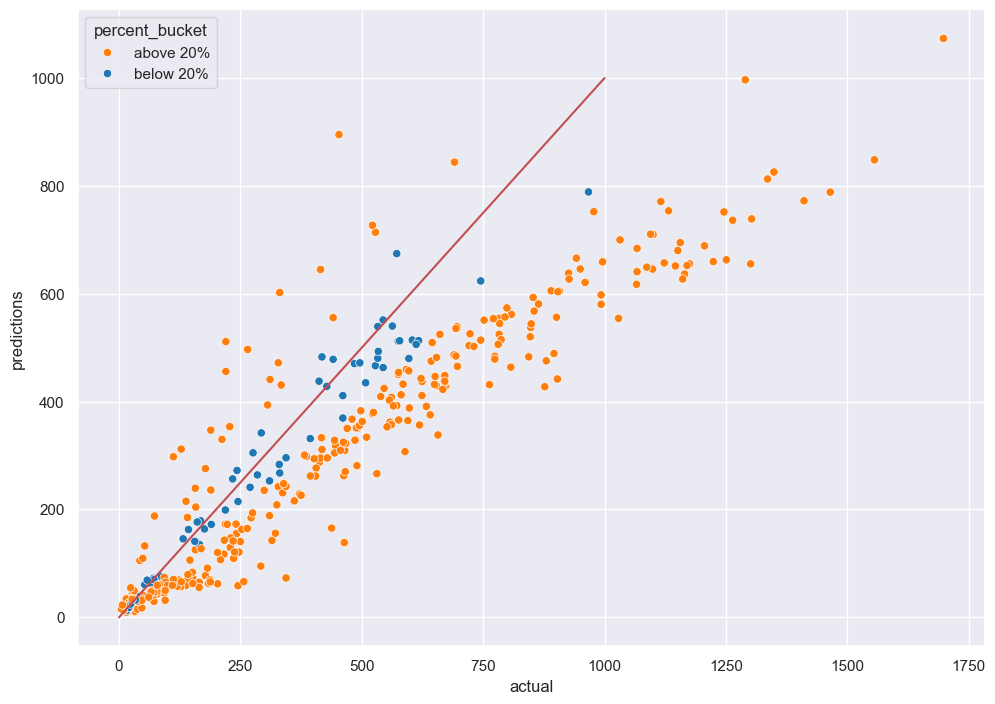

-----------------------------------------------------------------------------




-------------------------------- CTRL RESULTS ---------------------------------

 Within 5%: 3.3854166666666665%
 Within 10%: 7.8125%
 Within 20%: 20.052083333333336%
 R^2: 0.6721754987546631%
 RMSE: 208.44569627480027
 Mean Absolute Error: 146.68480225000002
 Median Aboslute Error: 106.46463000000001


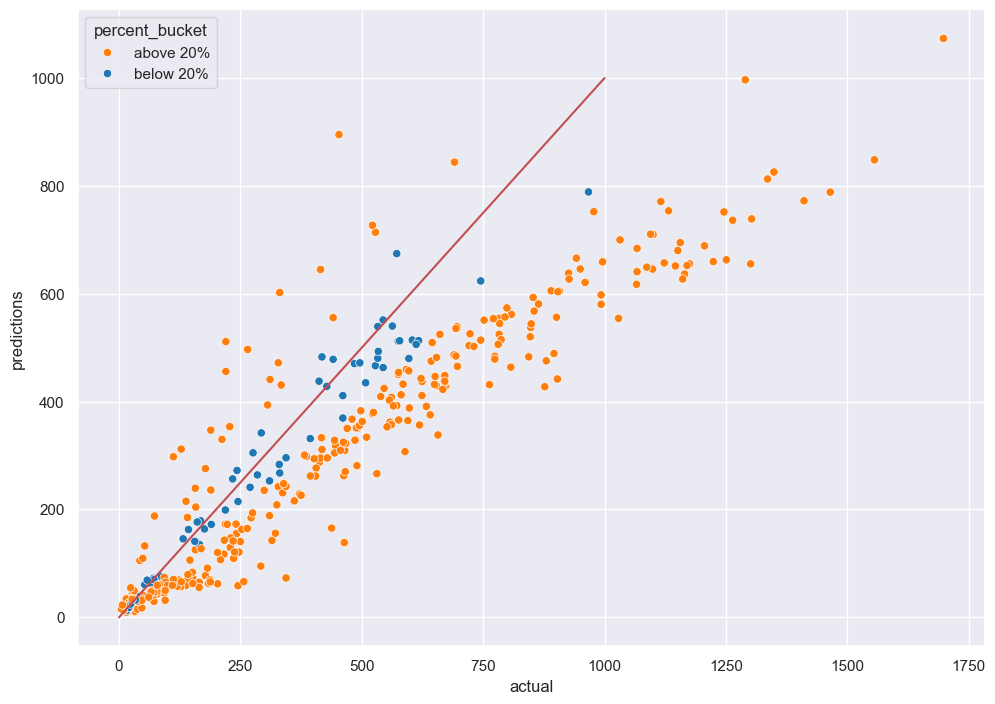

-----------------------------------------------------------------------------




-------------------------------- MODEL_0 RESULTS ---------------------------------

 Within 5%: 4.166666666666666%
 Within 10%: 8.59375%
 Within 20%: 17.708333333333336%
 R^2: 0.6393990069568201%
 RMSE: 218.61788447649735
 Mean Absolute Error: 157.20097034557293
 Median Aboslute Error: 104.612665


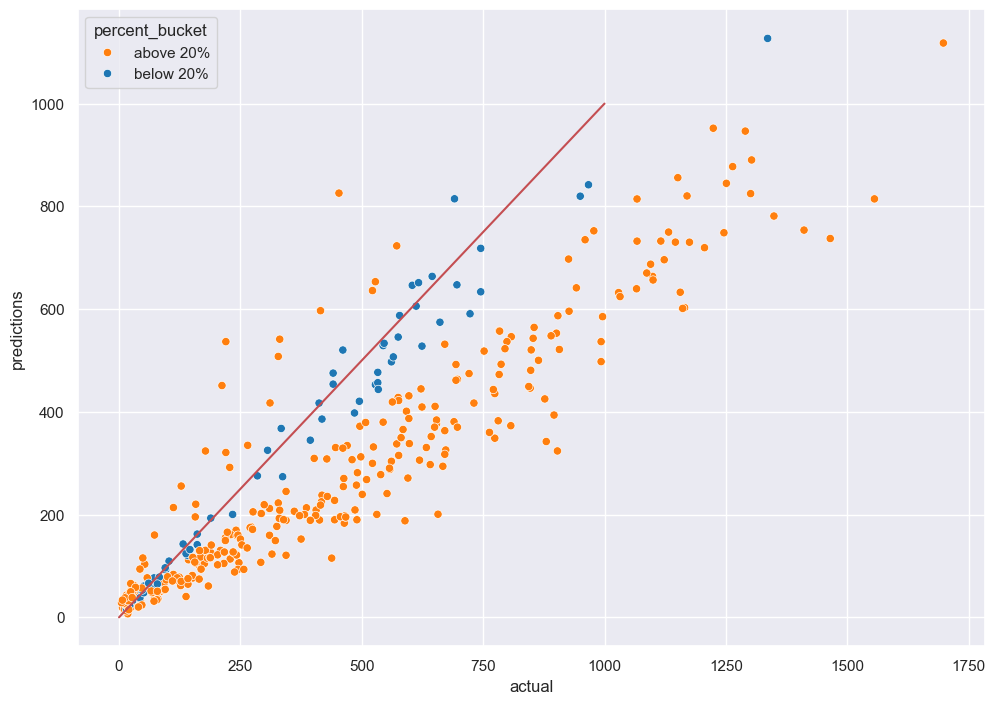

-----------------------------------------------------------------------------




-------------------------------- MODEL_1 RESULTS ---------------------------------

 Within 5%: 4.427083333333334%
 Within 10%: 10.15625%
 Within 20%: 23.4375%
 R^2: 0.699144953194431%
 RMSE: 199.68749951233806
 Mean Absolute Error: 142.29739697135417
 Median Aboslute Error: 101.35904


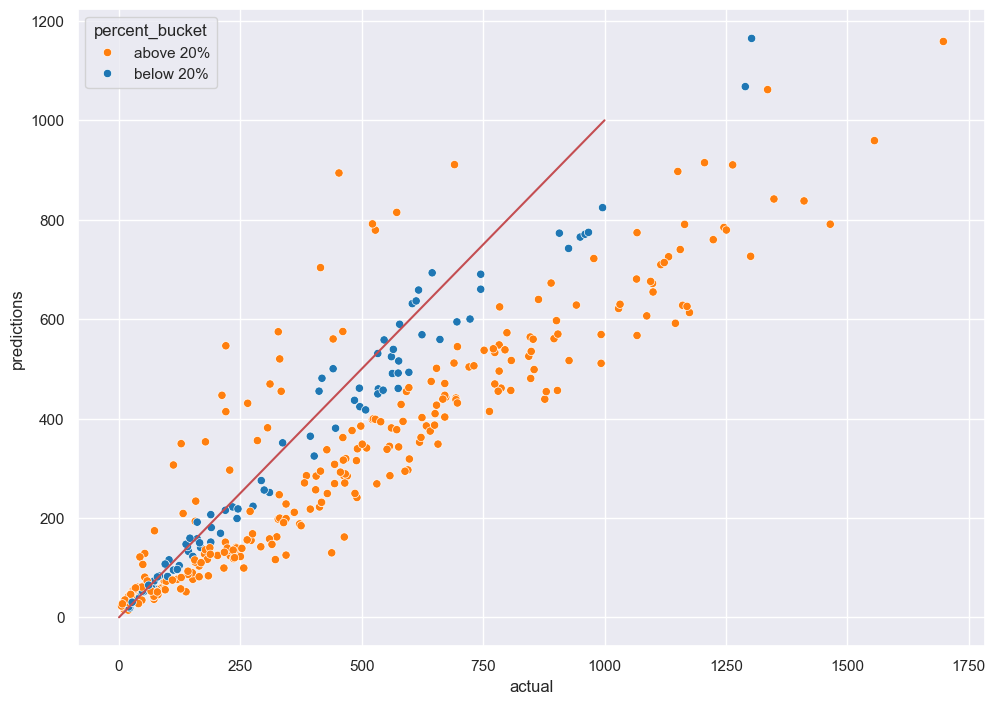

-----------------------------------------------------------------------------




-------------------------------- MODEL_2 RESULTS ---------------------------------

 Within 5%: 5.46875%
 Within 10%: 9.114583333333332%
 Within 20%: 21.09375%
 R^2: 0.6089396472672173%
 RMSE: 227.66387419981703
 Mean Absolute Error: 156.86888167447918
 Median Aboslute Error: 96.50665500000001


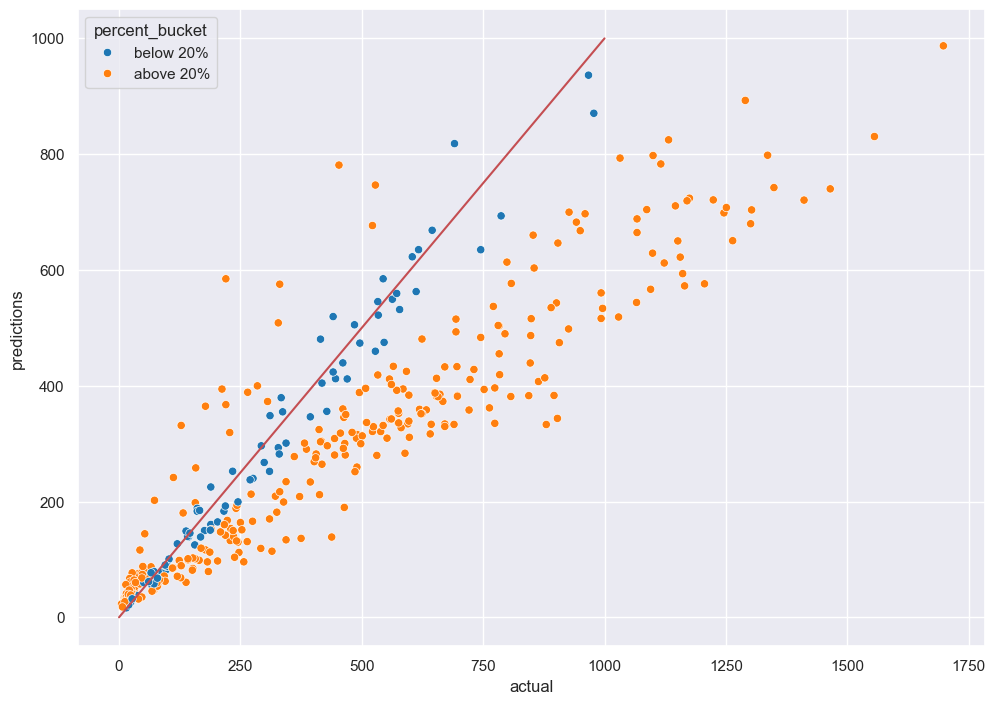

-----------------------------------------------------------------------------




-------------------------------- MODEL_3 RESULTS ---------------------------------

 Within 5%: 6.25%
 Within 10%: 11.979166666666668%
 Within 20%: 24.479166666666664%
 R^2: 0.7637643308764058%
 RMSE: 176.94771724779412
 Mean Absolute Error: 126.55758486197915
 Median Aboslute Error: 91.13413999999999


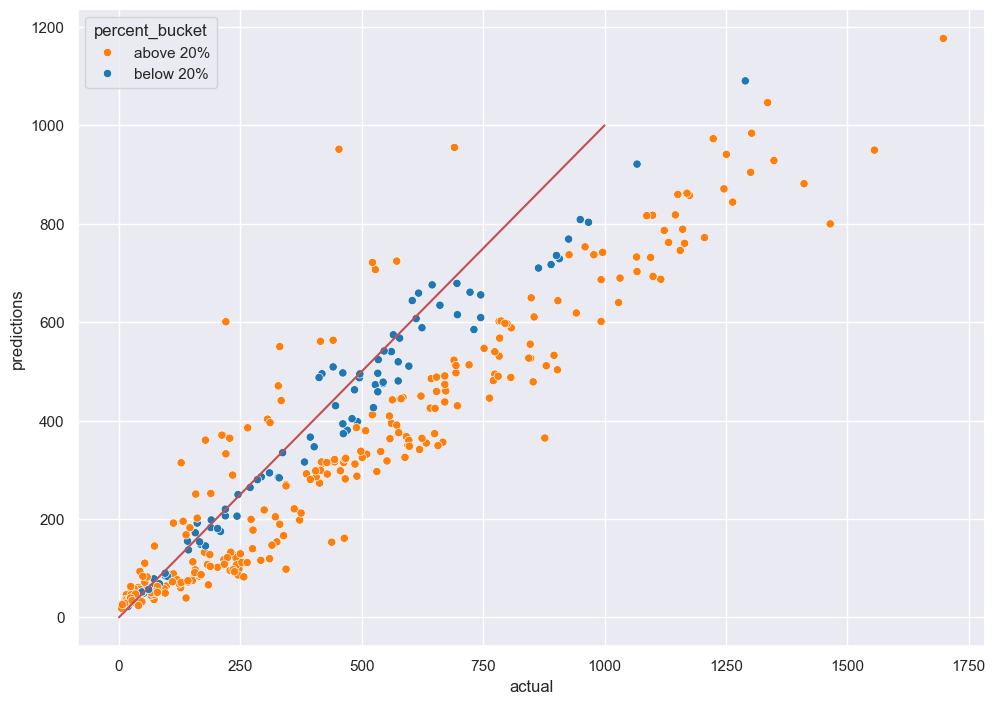

-----------------------------------------------------------------------------




-------------------------------- MODEL_4 RESULTS ---------------------------------

 Within 5%: 5.208333333333334%
 Within 10%: 9.895833333333332%
 Within 20%: 21.875%
 R^2: 0.7163589211225251%
 RMSE: 193.8906169402348
 Mean Absolute Error: 139.29449073307293
 Median Aboslute Error: 100.89580999999998


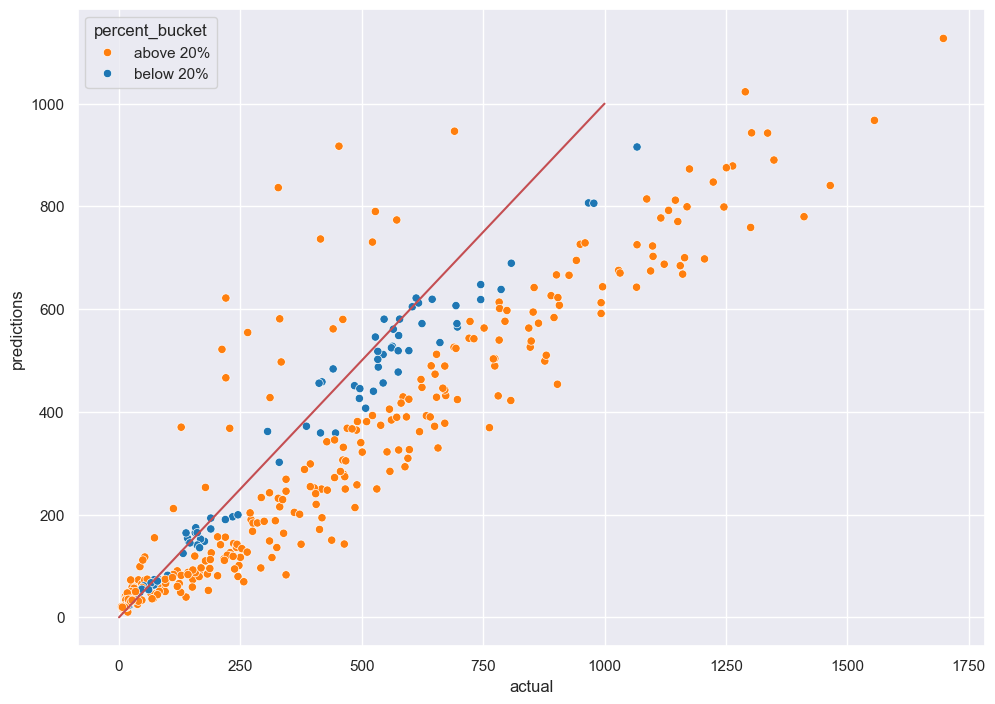

-----------------------------------------------------------------------------




-------------------------------- MODEL_5 RESULTS ---------------------------------

 Within 5%: 3.6458333333333335%
 Within 10%: 9.635416666666668%
 Within 20%: 20.572916666666664%
 R^2: 0.7128668344037048%
 RMSE: 195.08052141715217
 Mean Absolute Error: 138.87300006536458
 Median Aboslute Error: 98.03363999999999


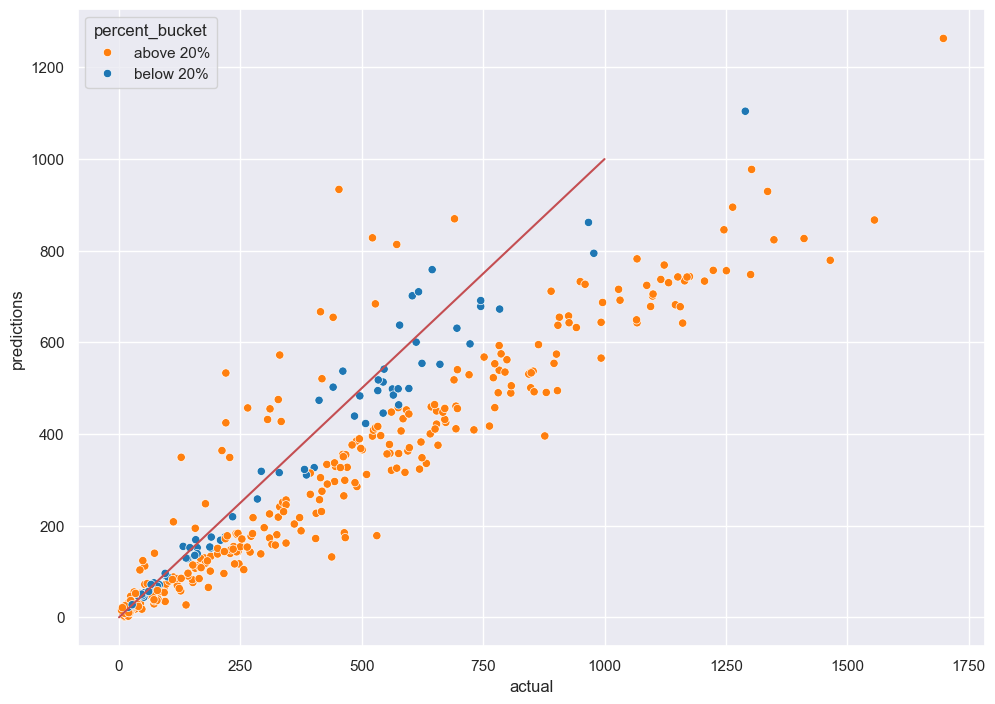

-----------------------------------------------------------------------------




-------------------------------- MODEL_BEST RESULTS ---------------------------------

 Within 5%: 6.510416666666667%
 Within 10%: 14.0625%
 Within 20%: 34.63541666666667%
 R^2: 0.7630818344152449%
 RMSE: 177.203138226738
 Mean Absolute Error: 122.31195688255207
 Median Aboslute Error: 79.064925


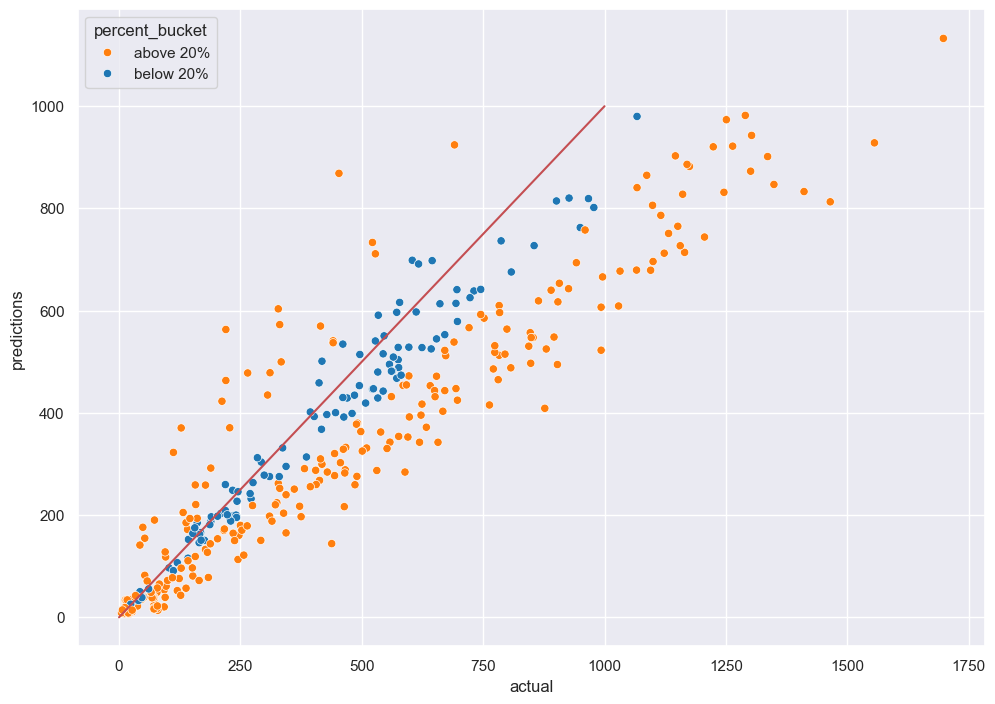

-----------------------------------------------------------------------------




-------------------------------- MODLE_LSE RESULTS ---------------------------------

 Within 5%: 3.6458333333333335%
 Within 10%: 8.072916666666668%
 Within 20%: 20.052083333333336%
 R^2: 0.6692874220634879%
 RMSE: 209.36186798935285
 Mean Absolute Error: 156.41665046752604
 Median Aboslute Error: 110.485425


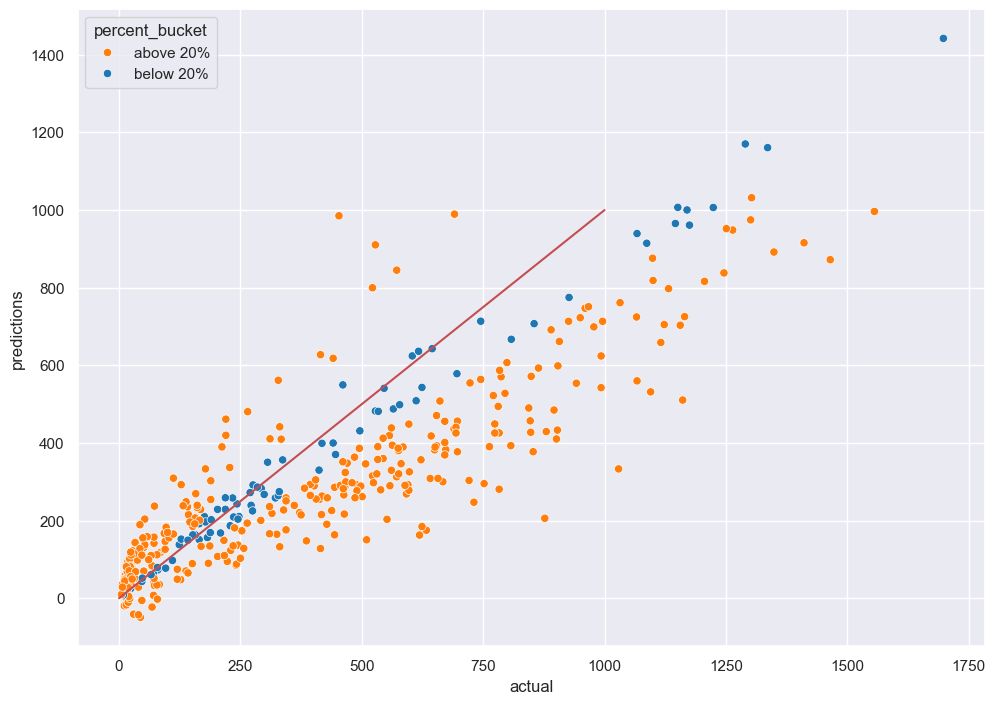

-----------------------------------------------------------------------------






In [11]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
for team_results in results_dict.items():
  testfinal = team_results[1]['dataset']
  # print(team_results['dataset'])
  # print(f"R-Squared Value: {r2}")
  print(f"-------------------------------- {team_results[0].upper()} RESULTS ---------------------------------\n")
  print(f" Within 5%: {team_results[1]['Percent of bikes within 5 percent']}%\n",
  f"Within 10%: {team_results[1]['Percent of bikes within 10 percent']}%\n",
  f"Within 20%: {team_results[1]['Percent of bikes within 20 percent']}%\n",
  f"R^2: {team_results[1]['R2']}%\n",
  f"RMSE: {team_results[1]['RMSE']}\n",
  f"Mean Absolute Error: {team_results[1]['Mean Abs Error']}\n",
  f"Median Aboslute Error: {team_results[1]['Median Abs Error']}")


  color_dict = dict({'below 20%':'tab:blue',
                    'above 20%': 'tab:orange'})
  # print(testfinal['abspercentmiss'].describe(percentiles=[.1,.2,.3,.4,.5,.6,.7,.8,.9,.95]))
  xlims=(0,1e3)
  # ylims=(0,1e3)
  ax = sns.scatterplot(data=testfinal,x='actual',y='predictions',hue="percent_bucket",palette=color_dict)
  # ax.set(xscale="log", yscale="log", xlim=xlims, ylim=ylims)
  ax.plot(xlims,xlims, color='r')
  # plt.legend(labels=['perfect',"below 5",'above 5','10-20%','above 20'])
  plt.show()
  print(f"-"*77)
  print("\n"*3)


-------------------------------- BEST_SHORT_TRAIN RESULTS ---------------------------------



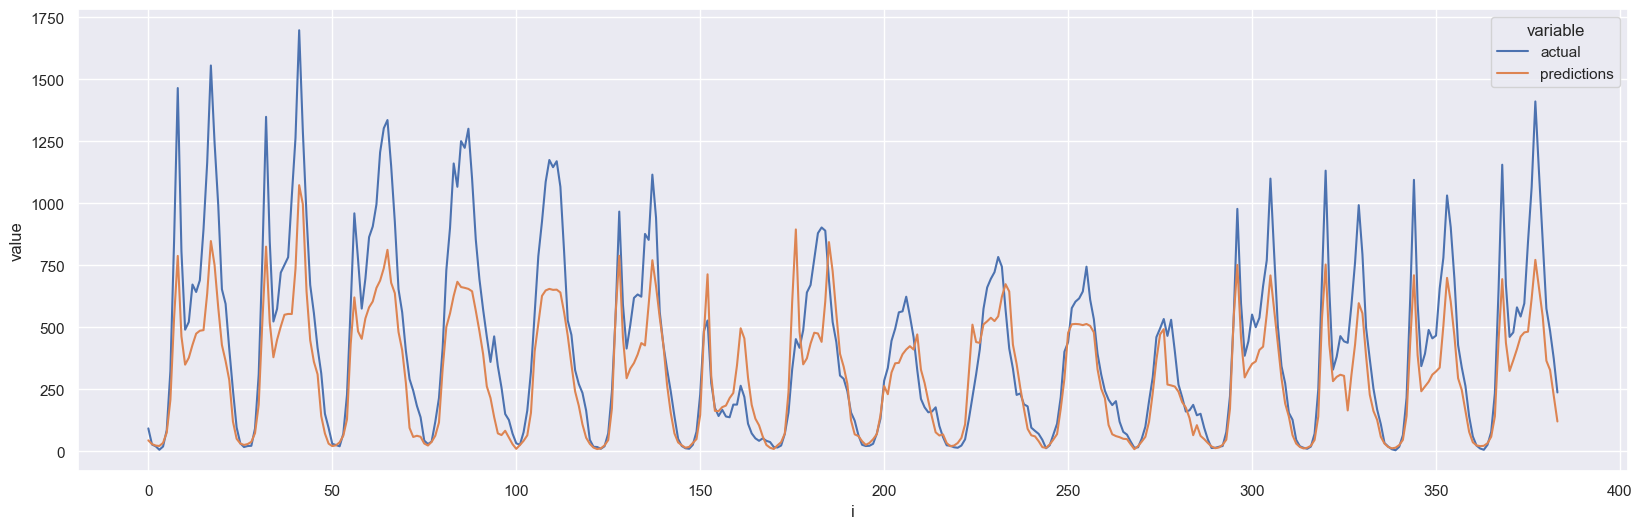

-----------------------------------------------------------------------------




-------------------------------- CTRL RESULTS ---------------------------------



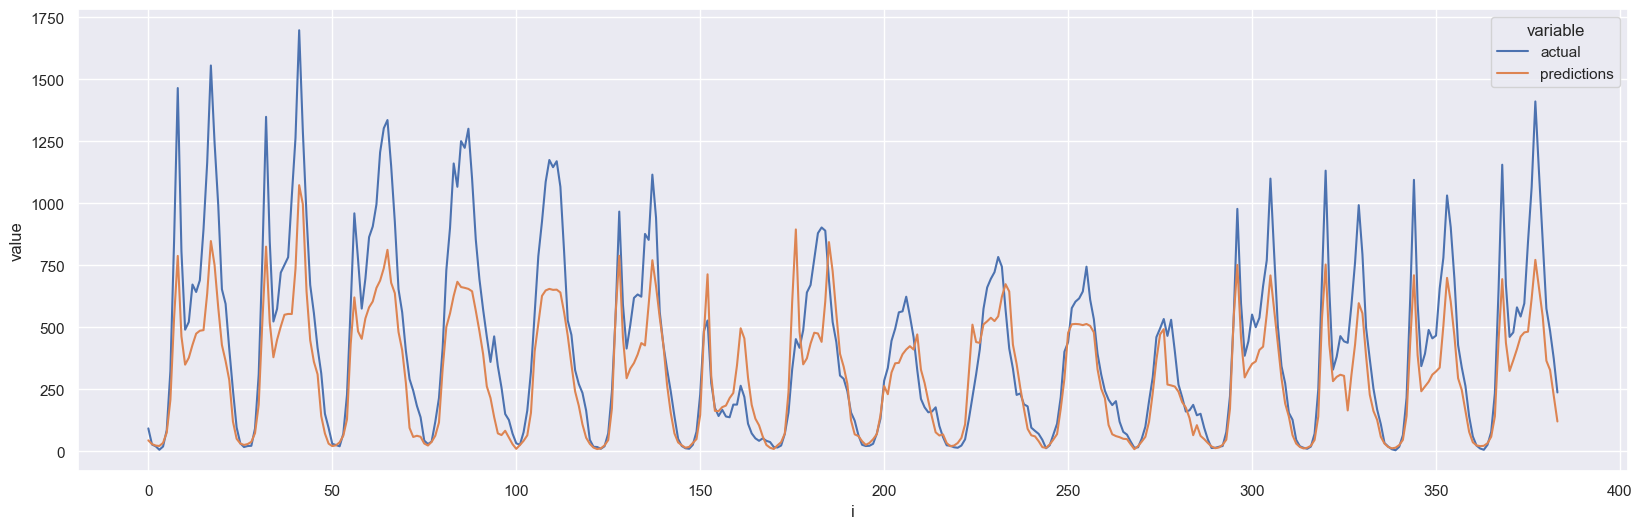

-----------------------------------------------------------------------------




-------------------------------- MODEL_0 RESULTS ---------------------------------



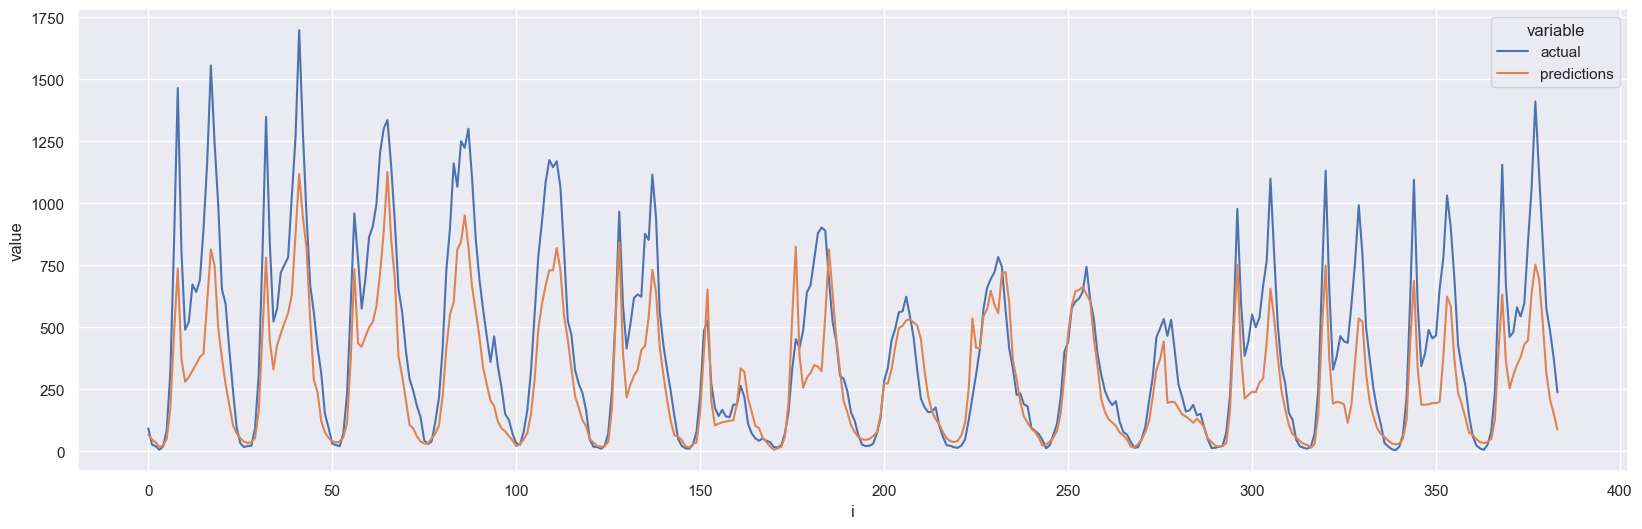

-----------------------------------------------------------------------------




-------------------------------- MODEL_1 RESULTS ---------------------------------



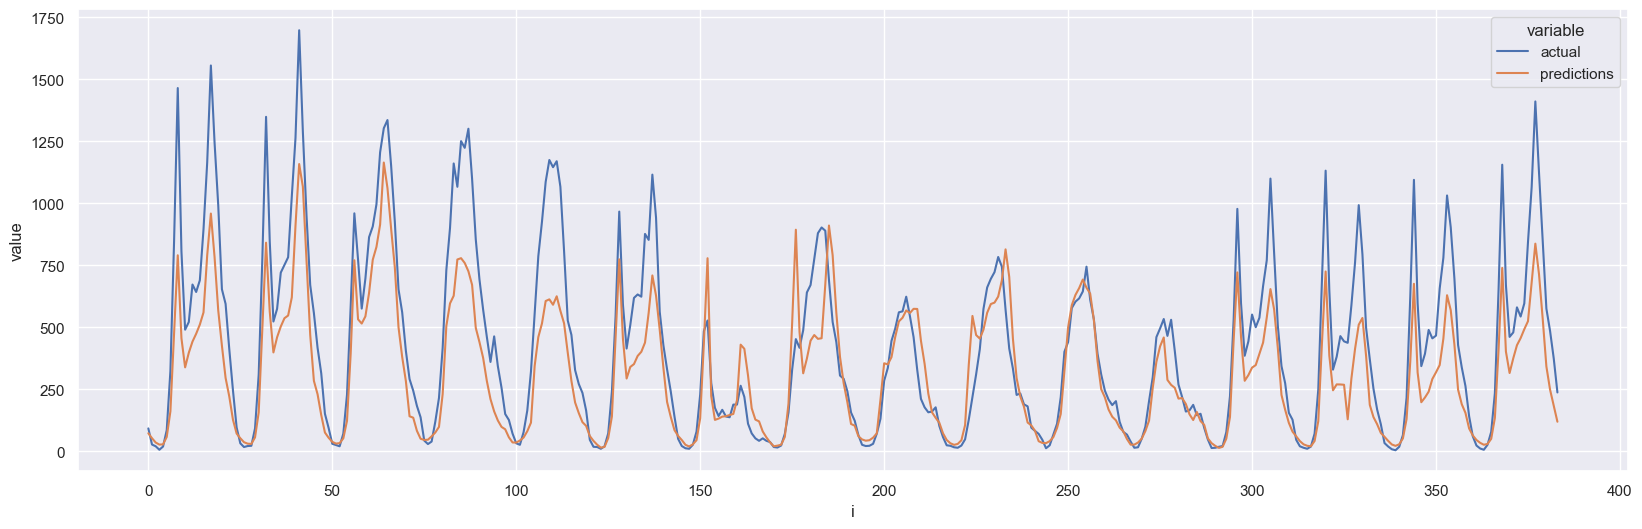

-----------------------------------------------------------------------------




-------------------------------- MODEL_2 RESULTS ---------------------------------



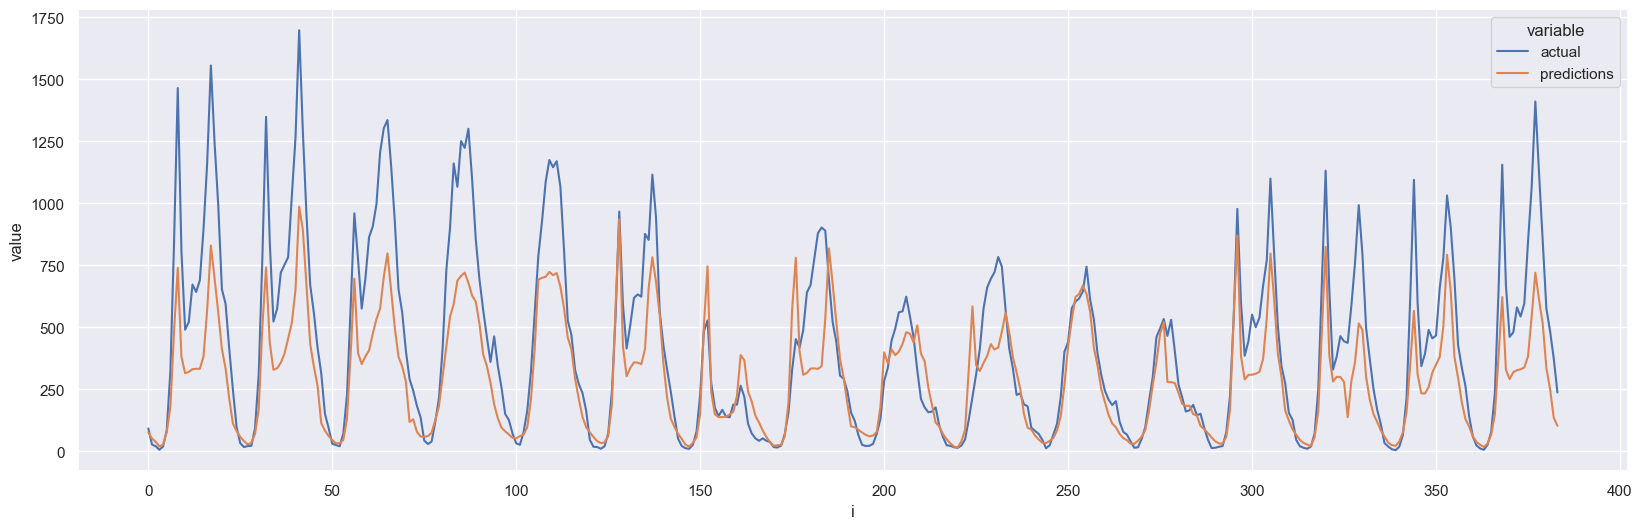

-----------------------------------------------------------------------------




-------------------------------- MODEL_3 RESULTS ---------------------------------



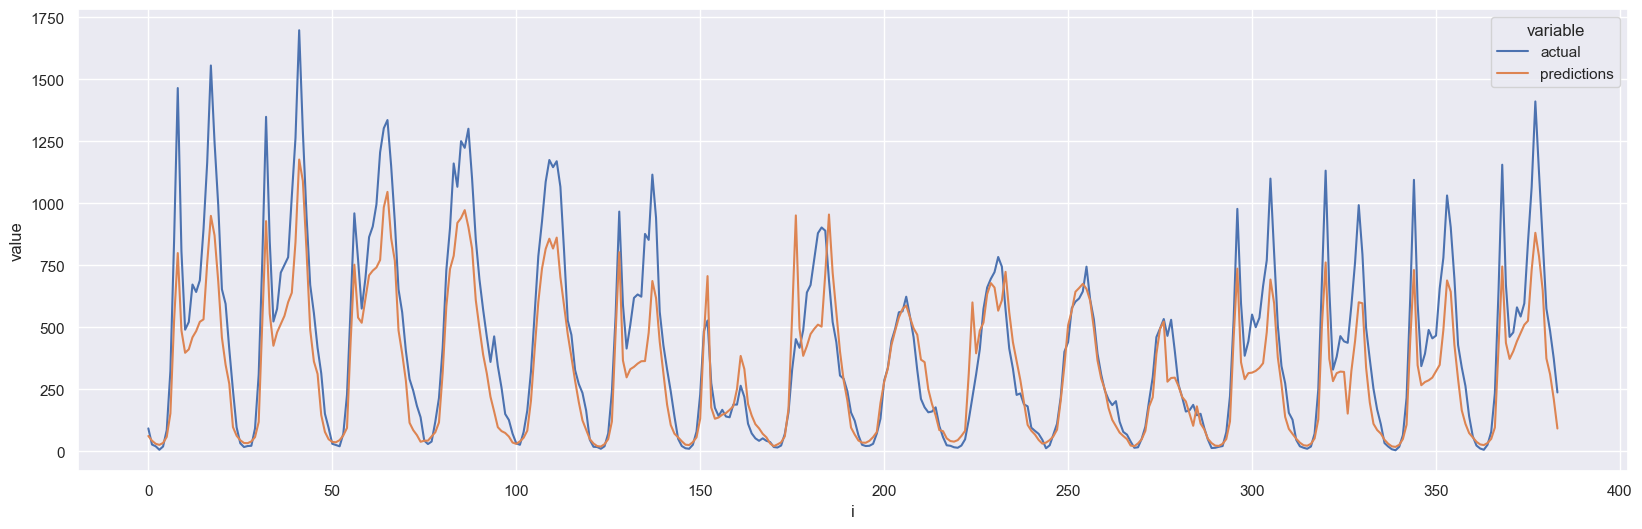

-----------------------------------------------------------------------------




-------------------------------- MODEL_4 RESULTS ---------------------------------



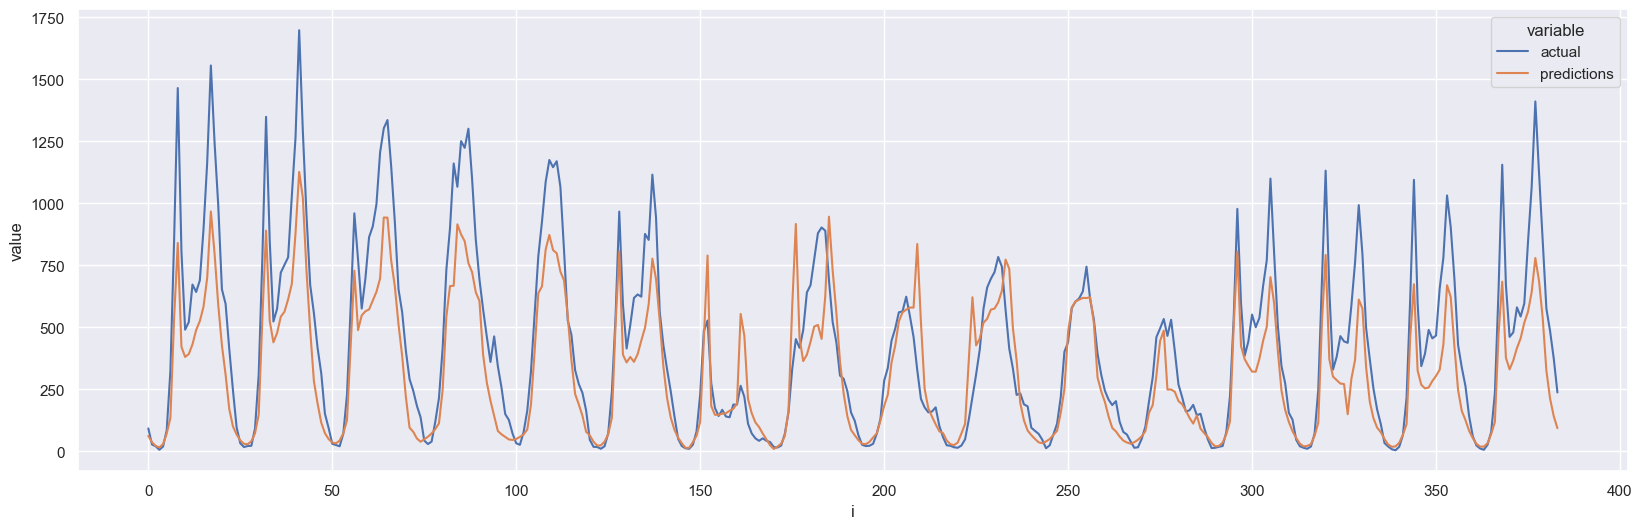

-----------------------------------------------------------------------------




-------------------------------- MODEL_5 RESULTS ---------------------------------



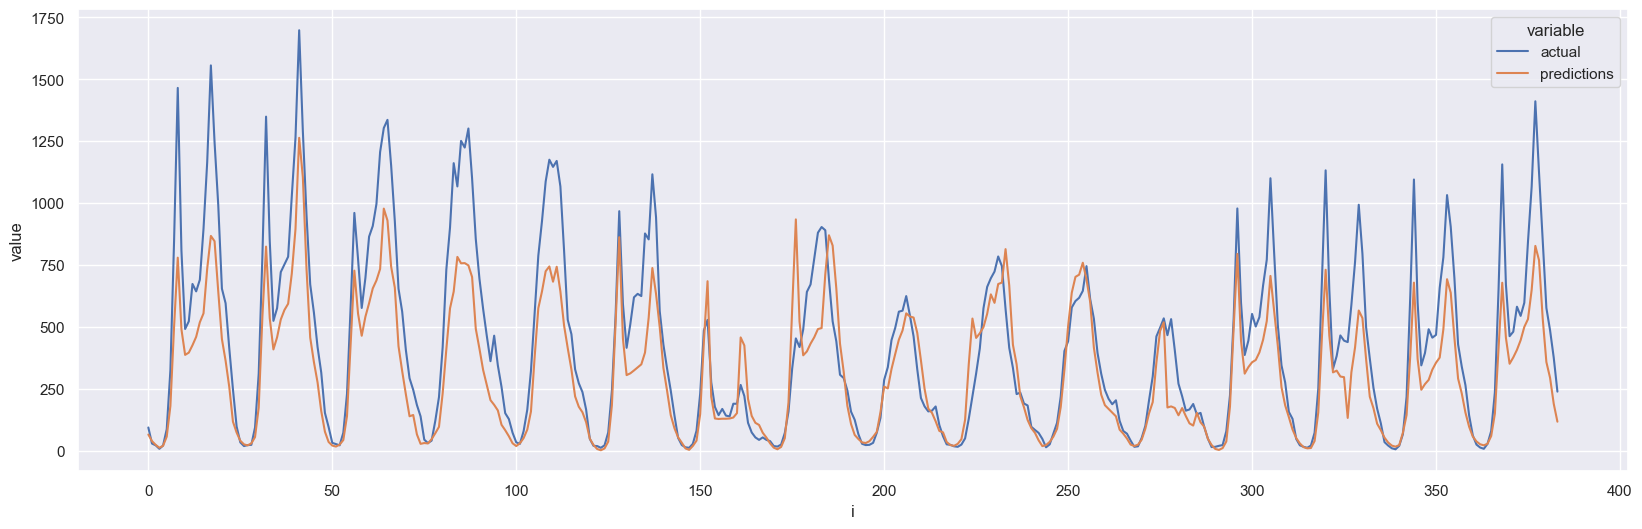

-----------------------------------------------------------------------------




-------------------------------- MODEL_BEST RESULTS ---------------------------------



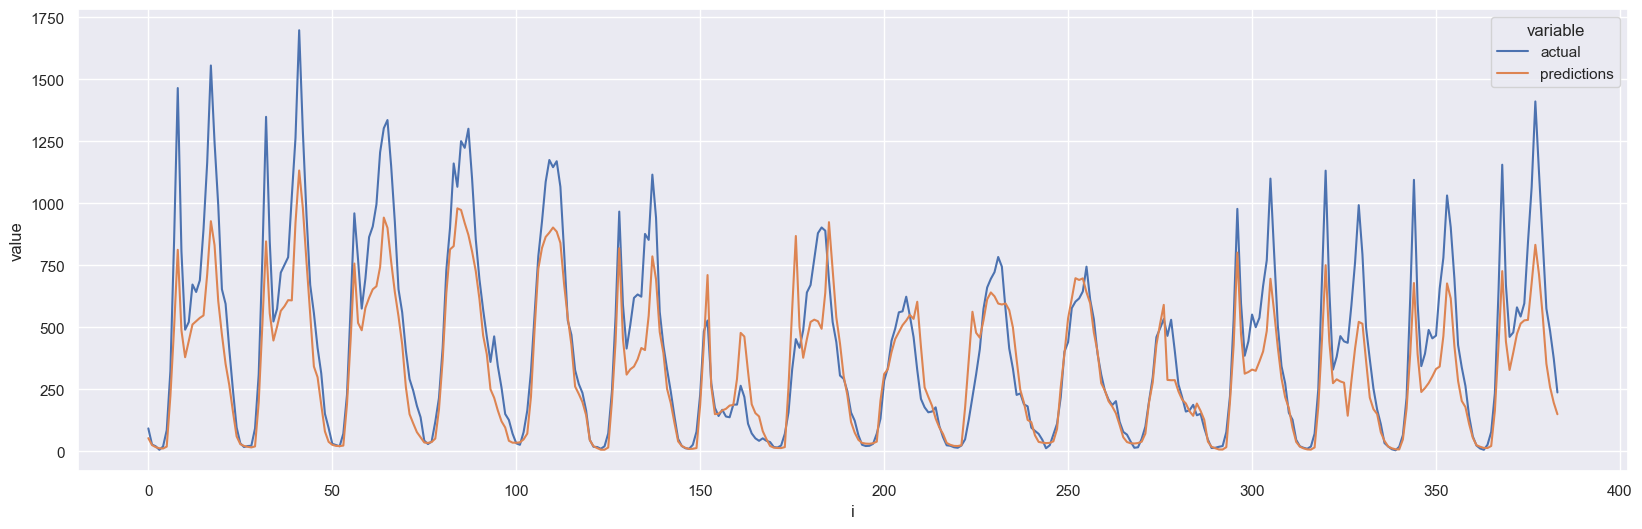

-----------------------------------------------------------------------------




-------------------------------- MODLE_LSE RESULTS ---------------------------------



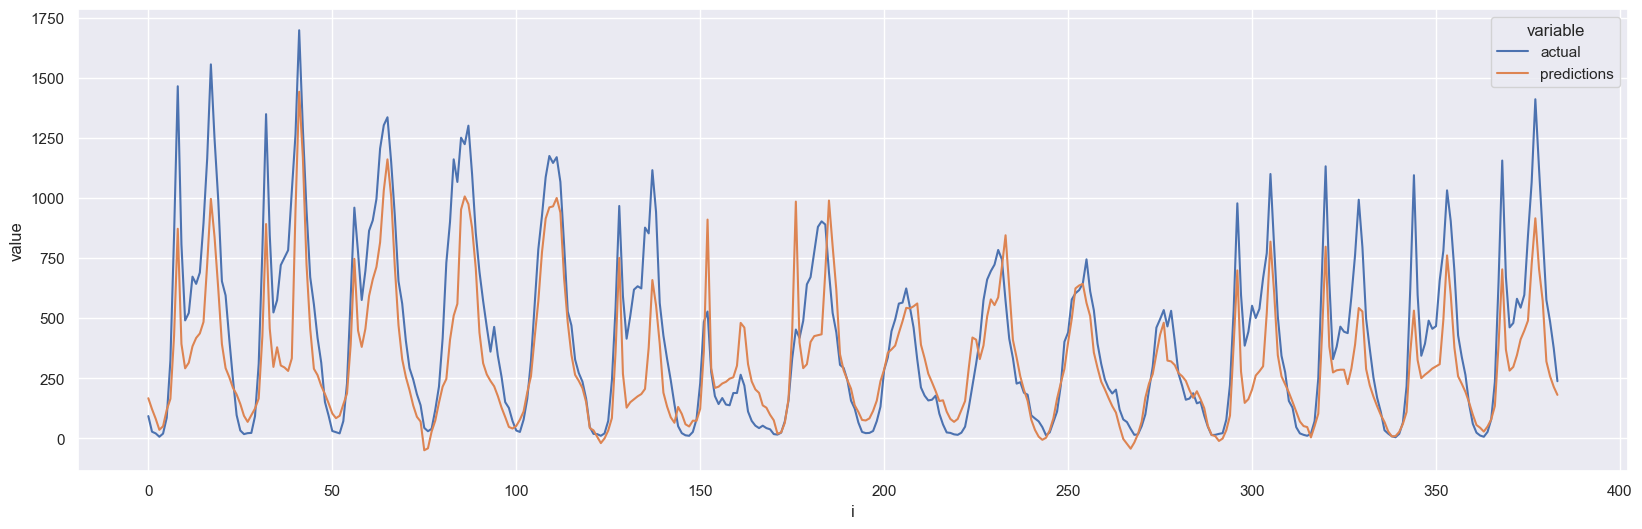

-----------------------------------------------------------------------------






In [12]:
pd.set_option('mode.chained_assignment',None)
sns.set(rc={'figure.figsize':(20,6)})
for team_results in results_dict.items():
  print(f"-------------------------------- {team_results[0].upper()} RESULTS ---------------------------------\n")
  testfinal = team_results[1]['dataset']
  testfinal = testfinal[['actual', 'predictions']]
  testfinal['i'] = testfinal.index
  testfinal=testfinal.melt(['i'])

  ax = sns.lineplot(data=testfinal,x='i',y='value',hue='variable')

  plt.show()
  print(f"-"*77)
  print("\n"*3)